# Clustering Urban Mobility Patterns Using Bike-Sharing Data
**Course assignment notebook — built step by step**

This notebook follows the assignment structure exactly:
1. Data Preparation & Feature Engineering
2. Clustering Methods (K-Means, AGNES, DBSCAN)
3. Evaluation & Comparison
4. Cluster Interpretation & Validation
5. Theoretical Questions (answered in the report, referenced here)


## 0. Setup
Import libraries and set a fixed random seed for reproducibility.

In [2]:
# Libraries will be added here as we need them, one step at a time.
import numpy as np
import pandas as pd

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## Part 1: Data Preparation and Feature Engineering

### 1.1 Inspect and Clean the Data
- Load `hour.csv`
- Check missing values, invalid values, duplicates
- Convert `dteday` to datetime
- Verify each date has a reasonable number of hourly observations
- Identify and handle unusual/incomplete days

In [3]:
df = pd.read_csv("data/hour.csv") 

df['dteday'] = pd.to_datetime(df['dteday'])
print("Shape of the dataset:", df.shape)

# Check for missing values
total_missing = df.isnull().sum().sum()
print(f"\nTotal missing values in the dataset: {total_missing}")

# Check for duplicate rows, and duplicate (date, hour) pairs
duplicated_rows = df.duplicated().sum()
print(f"\nNumber of duplicated rows in the dataset: {duplicated_rows}")

duplicate_date_hour = df.duplicated(subset=['dteday', 'hr']).sum()
print(f"Duplicate (date, hour) pairs: {duplicate_date_hour}\n")

for col in ['temp', 'atemp', 'hum', 'windspeed']:
    print(f"{col}: min={df[col].min()}, max={df[col].max()}")

hourly_counts = df.groupby('dteday').size()
print(f"\nHourly counts: {hourly_counts.shape[0]}")
print(f"Days with all 24 hours present: {(hourly_counts == 24).sum()}")
print(f"Days missing at least 1 hour: {(hourly_counts < 24).sum()}")

# Decide a cutoff for "usable" days
MIN_HOURS_PER_DAY = 22
complete_days = hourly_counts[hourly_counts >= MIN_HOURS_PER_DAY].index
incomplete_days = hourly_counts[hourly_counts < MIN_HOURS_PER_DAY]

print(f"\nDays kept (>= {MIN_HOURS_PER_DAY} hours): {len(complete_days)}")
print(f"Days dropped (< {MIN_HOURS_PER_DAY} hours): {len(incomplete_days)}")
print(incomplete_days.sort_values())

# clean data
df_clean = df[df['dteday'].isin(complete_days)].copy()
print("\nRows remaining after filtering:", df_clean.shape[0])

Shape of the dataset: (17379, 17)

Total missing values in the dataset: 0

Number of duplicated rows in the dataset: 0
Duplicate (date, hour) pairs: 0

temp: min=0.02, max=1.0
atemp: min=0.0, max=1.0
hum: min=0.0, max=1.0
windspeed: min=0.0, max=0.8507

Hourly counts: 731
Days with all 24 hours present: 655
Days missing at least 1 hour: 76

Days kept (>= 22 hours): 723
Days dropped (< 22 hours): 8
dteday
2012-10-29     1
2011-01-27     8
2012-10-30    11
2011-01-18    12
2011-01-26    16
2011-08-28    17
2011-02-22    18
2011-08-27    18
dtype: int64

Rows remaining after filtering: 17278


### 1.2 Generate Daily Mobility Features
Aggregate hourly records into one row per day.

In [4]:
# Aggregate the cleaned hourly records into one row per day 
daily_agg = df_clean.groupby('dteday').agg(
    total_rentals=('cnt', 'sum'),
    avg_hourly_rentals=('cnt', 'mean'),
    max_hourly_rentals=('cnt', 'max'),
    std_hourly_rentals=('cnt', 'std'),
    total_casual=('casual', 'sum'),
    total_registered=('registered', 'sum'),
    avg_temp=('temp', 'mean'),
    avg_atemp=('atemp', 'mean'),
    avg_hum=('hum', 'mean'),
    avg_windspeed=('windspeed', 'mean'),
    season=('season', 'first'),
    yr=('yr', 'first'),
    mnth=('mnth', 'first'),
    holiday=('holiday', 'first'),
    weekday=('weekday', 'first'),
    workingday=('workingday', 'first'),
    weathersit=('weathersit', lambda x: x.mode()[0])  
).reset_index()

# Filter Morning and evening peak hours 
morning_sum = df_clean[df_clean['hr'].between(6, 9)].groupby('dteday')['cnt'].sum().rename('morning_rentals')
evening_sum = df_clean[df_clean['hr'].between(16, 19)].groupby('dteday')['cnt'].sum().rename('evening_rentals')

# Merge to daily_agg
daily_agg = daily_agg.merge(morning_sum, on='dteday', how='left').merge(evening_sum, on='dteday', how='left')
daily_agg[['morning_rentals', 'evening_rentals']] = daily_agg[['morning_rentals', 'evening_rentals']].fillna(0)

daily_agg['morning_peak_share'] = daily_agg['morning_rentals'] / daily_agg['total_rentals']
daily_agg['evening_peak_share'] = daily_agg['evening_rentals'] / daily_agg['total_rentals']
daily_agg['offpeak_share'] = 1 - daily_agg['morning_peak_share'] - daily_agg['evening_peak_share']

# Casual and registered user proportions 
daily_agg['casual_prop'] = daily_agg['total_casual'] / daily_agg['total_rentals']
daily_agg['registered_prop'] = daily_agg['total_registered'] / daily_agg['total_rentals']

print("\nDaily aggregated dataset shape:", daily_agg.shape)
daily_agg.head()


Daily aggregated dataset shape: (723, 25)


,dteday,total_rentals,avg_hourly_rentals,max_hourly_rentals,std_hourly_rentals,total_casual,total_registered,avg_temp,avg_atemp,avg_hum,...,weekday,workingday,weathersit,morning_rentals,evening_rentals,morning_peak_share,evening_peak_share,offpeak_share,casual_prop,registered_prop
0,2011-01-01,985,41.041667,110,34.292196,331,654,0.344167,0.363625,0.805833,...,6,0,1,27,232,0.027411,0.235533,0.737056,0.336041,0.663959
1,2011-01-02,801,34.826087,93,29.785067,131,670,0.363478,0.353739,0.696087,...,0,0,2,31,224,0.038702,0.279650,0.681648,0.163546,0.836454
2,2011-01-03,1349,61.318182,157,48.792453,120,1229,0.196364,0.189405,0.437273,...,1,1,1,336,500,0.249073,0.370645,0.380282,0.088955,0.911045
3,2011-01-04,1562,67.913043,212,59.889985,108,1454,0.200000,0.212122,0.590435,...,2,1,1,409,589,0.261844,0.377081,0.361076,0.069142,0.930858
4,2011-01-05,1600,69.565217,195,58.427753,82,1518,0.226957,0.229270,0.436957,...,3,1,1,431,580,0.269375,0.362500,0.368125,0.051250,0.948750


### 1.3 Prepare the Clustering Data
- Check distributions / skew
- Handle correlated or redundant features
- Standardize features
- Justify any removed features

In [5]:
from sklearn.preprocessing import StandardScaler

candidate_features = ['total_rentals', 'avg_hourly_rentals', 'max_hourly_rentals', 'std_hourly_rentals',
                      'morning_peak_share', 'evening_peak_share', 'offpeak_share',
                      'casual_prop', 'registered_prop', 'avg_temp', 'avg_atemp', 'avg_hum', 'avg_windspeed']

# Check skewness of candidate features
print("Skewness of each candidate feature:")
print(daily_agg[candidate_features].skew().sort_values(ascending=False))

# Look for redundant / highly correlated features
corr_matrix = daily_agg[candidate_features].corr()
print("\nPairs with |correlation| > 0.85:")
for i in range(len(candidate_features)):
    for j in range(i + 1, len(candidate_features)):
        c = corr_matrix.iloc[i, j]
        if abs(c) > 0.85:
            print(f"{candidate_features[i]} <-> {candidate_features[j]}: {c:.3f}")

# Handle correlated or redundant features
# 1. total_rentals is a constant multiple of avg_hourly_rentals (corr = 1.00)
#    since almost every day has ~24 hours -> drop total_rentals
# 2. offpeak_share is mathematically determined by the other two shares
#    (offpeak = 1 - morning - evening) - it carries zero new information,
#    so drop it rather than let it double-count morning/evening.
# 3. registered_prop is the exact complement of casual_prop (registered = 1 - casual, 
#    corr = -1.00) -> drop registered_prop
# 4. avg_atemp correlates 0.99 with avg_temp. Keeping both would let "temperature" count
#    almost twice as much as any other feature ->  drop avg_atemp, keep the more standard avg_temp.
# 5. max_hourly_rentals and std_hourly_rentals both correlate > 0.92 with avg_hourly_rentals and with each other. 
#    All three primarily captured overall rental *volume* rather than distinct behaviour.
#    -> cv_hourly_rentals (coefficient of variation) isolates how "spiky vs. flat" a day is independent of how busy it was 
daily_agg['cv_hourly_rentals'] = daily_agg['std_hourly_rentals'] / daily_agg['avg_hourly_rentals']
print("\ncv_hourly_rentals corr with avg_hourly_rentals:",
      round(daily_agg['cv_hourly_rentals'].corr(daily_agg['avg_hourly_rentals']), 3))

# Transformation to reduce skew uding square root
print("\ncasual_prop skew :",
      round(daily_agg['casual_prop'].skew(), 3), "->",
      round(daily_agg['casual_prop'].apply(lambda x: x ** 0.5).skew(), 3))
daily_agg['casual_prop_sqrt'] = daily_agg['casual_prop'] ** 0.5

print("avg_windspeed skew :",
      round(daily_agg['avg_windspeed'].skew(), 3), "->",
      round(daily_agg['avg_windspeed'].apply(lambda x: x ** 0.5).skew(), 3))
daily_agg['avg_windspeed_sqrt'] = daily_agg['avg_windspeed'] ** 0.5

# Final featureS for clustering
final_features = ['avg_hourly_rentals', 'cv_hourly_rentals', 'morning_peak_share', 'evening_peak_share',
                  'casual_prop_sqrt', 'avg_temp', 'avg_hum', 'avg_windspeed_sqrt']

# Check skewness of final features
final_corr = daily_agg[final_features].corr()
remaining_high_corr = []
for i in range(len(final_features)):
    for j in range(i + 1, len(final_features)):
        c = final_corr.iloc[i, j]
        if abs(c) > 0.85:
            remaining_high_corr.append((final_features[i], final_features[j], round(c, 3)))
print("\nRemaining |corr| > 0.85 in final feature set:", remaining_high_corr or "None")

# Standardize the final features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(daily_agg[final_features])
X_scaled = pd.DataFrame(X_scaled, columns=final_features, index=daily_agg.index)
X_scaled.head()

print("\nScaled feature means:", X_scaled.mean().round(3))
print("\nScaled feature std devs:", X_scaled.std().round(3))






Skewness of each candidate feature:
casual_prop           0.941105
avg_windspeed         0.682048
offpeak_share         0.680854
max_hourly_rentals    0.024638
avg_hourly_rentals   -0.024681
std_hourly_rentals   -0.025658
total_rentals        -0.030869
avg_temp             -0.057926
avg_hum              -0.068855
avg_atemp            -0.135142
morning_peak_share   -0.261408
evening_peak_share   -0.653484
registered_prop      -0.941105
dtype: float64

Pairs with |correlation| > 0.85:
total_rentals <-> avg_hourly_rentals: 1.000
total_rentals <-> max_hourly_rentals: 0.928
total_rentals <-> std_hourly_rentals: 0.975
avg_hourly_rentals <-> max_hourly_rentals: 0.928
avg_hourly_rentals <-> std_hourly_rentals: 0.975
max_hourly_rentals <-> std_hourly_rentals: 0.969
morning_peak_share <-> offpeak_share: -0.908
casual_prop <-> registered_prop: -1.000
avg_temp <-> avg_atemp: 0.992

cv_hourly_rentals corr with avg_hourly_rentals: -0.223

casual_prop skew : 0.941 -> 0.375
avg_windspeed skew : 0.682 

### 1.4 Exploratory Visualisation
- Histograms / boxplots
- Correlation heatmap
- Daily rental pattern plots
- PCA 2D visualisation

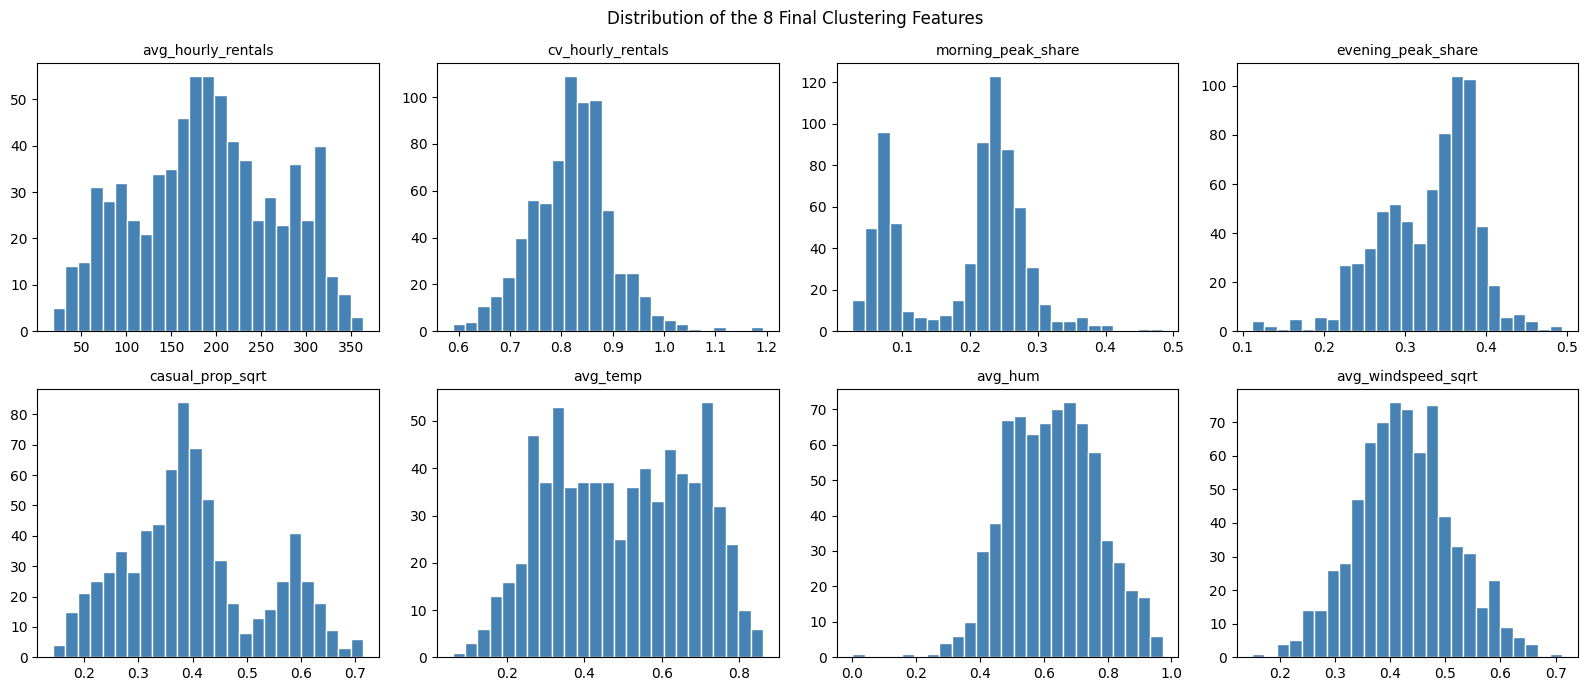

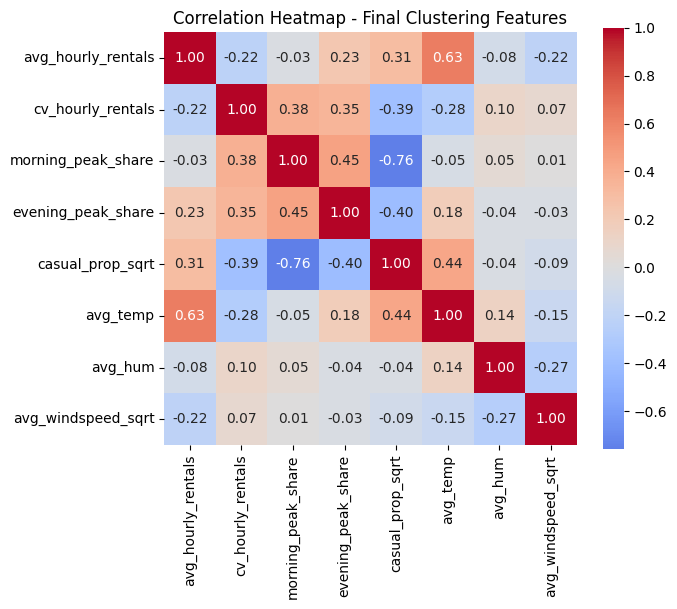

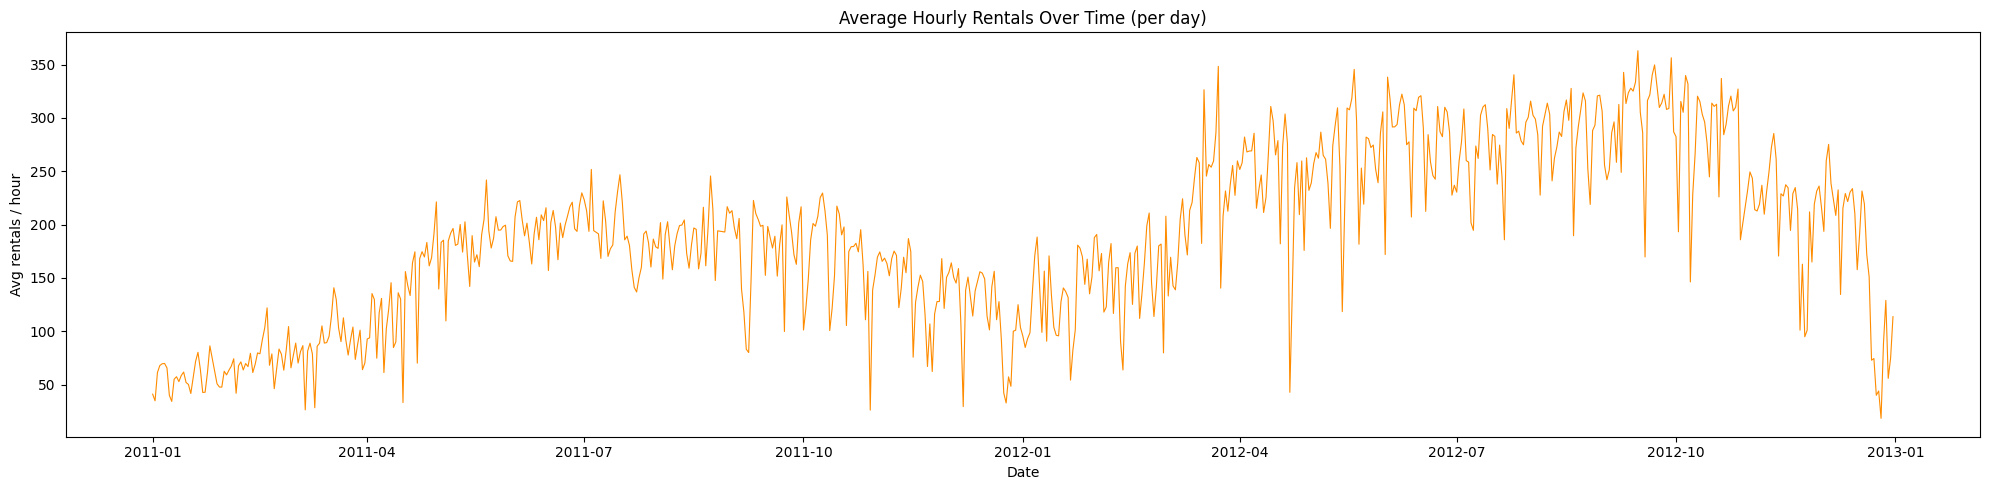

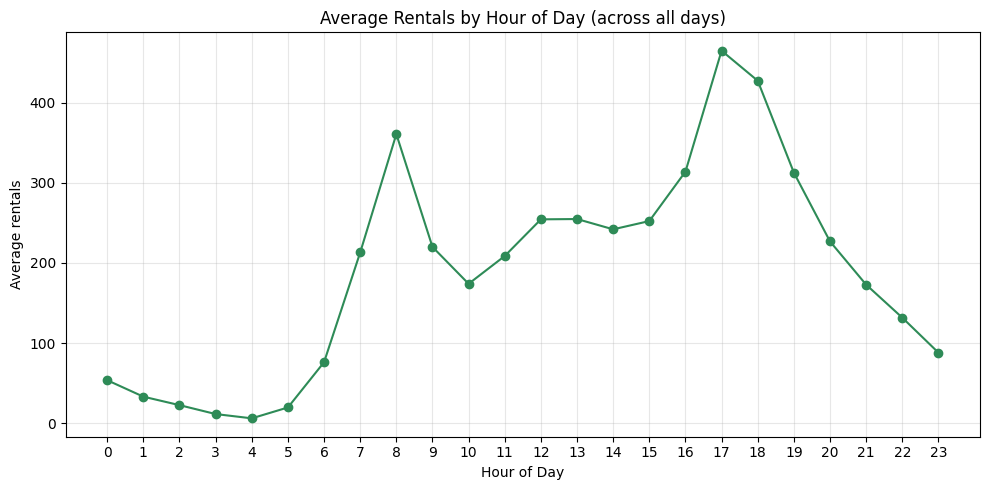

Busiest average hour: 17 with 464.6 avg rentals


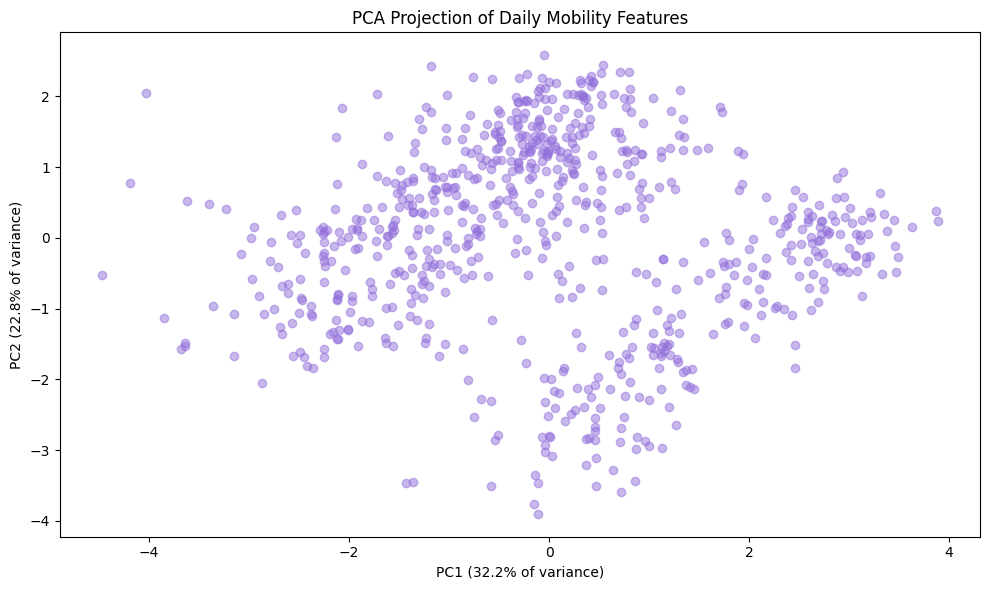

Variance captured by PC1 + PC2: 55.0%


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 1. Histogram of the final features
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for ax , feature in zip(axes, final_features):
    ax.hist(daily_agg[feature], bins=25, color='steelblue', edgecolor='white')
    ax.set_title(feature, fontsize=10)
plt.suptitle('Distribution of the 8 Final Clustering Features')
plt.tight_layout()
plt.show()

# 2. Correlation heatmap
plt.figure(figsize=(7, 6))
sns.heatmap(daily_agg[final_features].corr(), annot=True, fmt=".2f", 
            cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap - Final Clustering Features')
plt.tight_layout()
plt.show()

# 3. Daily rental pattern plots
# a. How busy the system was, day by day, across the full 2-year span
plt.figure(figsize=(20, 5))
plt.plot(daily_agg['dteday'], daily_agg['avg_hourly_rentals'], color='darkorange', linewidth=0.8)
plt.title('Average Hourly Rentals Over Time (per day)')
plt.xlabel('Date')
plt.ylabel('Avg rentals / hour')
plt.tight_layout()
plt.show()

# b. Average rentals for each hour of the day, averaged across all 723 days.
hourly_profile = df_clean.groupby('hr')['cnt'].mean()
plt.figure(figsize=(10, 5))
plt.plot(hourly_profile.index, hourly_profile.values, marker='o', color='seagreen')
plt.title('Average Rentals by Hour of Day (across all days)')
plt.xlabel('Hour of Day')
plt.ylabel('Average rentals')
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Busiest average hour:", hourly_profile.idxmax(), "with", round(hourly_profile.max(), 1), "avg rentals")

# 4. PCA 2D visualisation
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(pca_coords[:, 0], pca_coords[:, 1], alpha=0.5, color='mediumpurple')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% of variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% of variance)')
plt.title('PCA Projection of Daily Mobility Features')
plt.tight_layout()
plt.show()

print(f"Variance captured by PC1 + PC2: {pca.explained_variance_ratio_.sum()*100:.1f}%")


## Part 2: Apply and Analyse Clustering Methods

### 2.1 K-Means Clustering

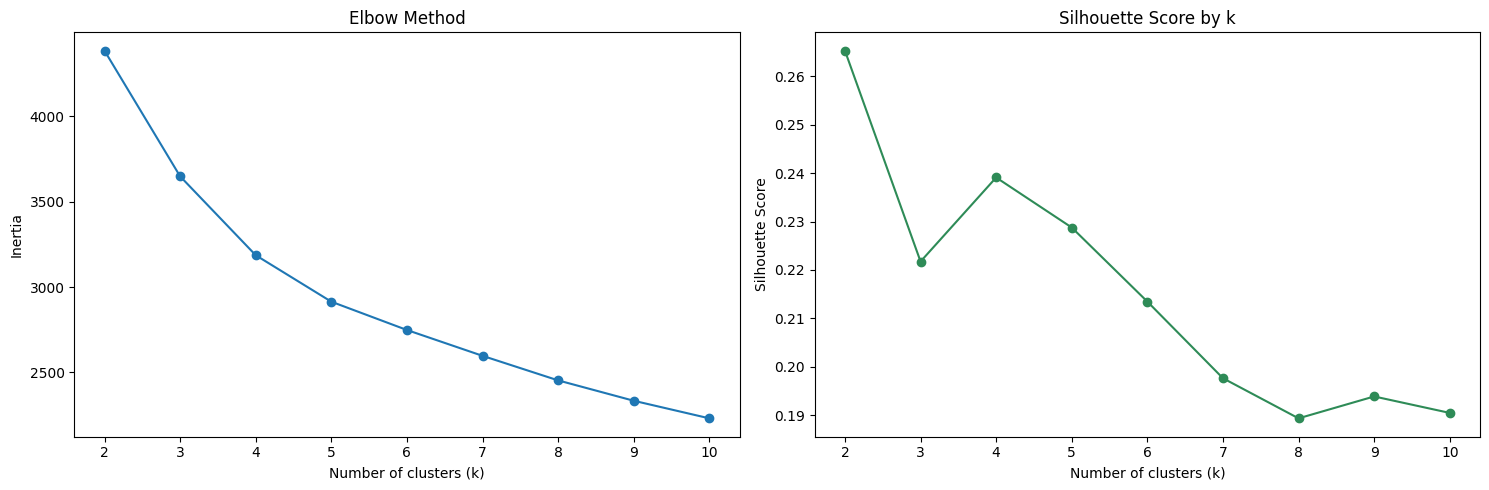

k=2: inertia=4384.6, silhouette=0.2653
k=3: inertia=3648.8, silhouette=0.2217
k=4: inertia=3186.7, silhouette=0.2391
k=5: inertia=2914.5, silhouette=0.2288
k=6: inertia=2748.6, silhouette=0.2135
k=7: inertia=2597.4, silhouette=0.1976
k=8: inertia=2453.5, silhouette=0.1893
k=9: inertia=2334.2, silhouette=0.1939
k=10: inertia=2231.2, silhouette=0.1905

Final cluster sizes:
kmeans_cluster
0    127
1    202
2    283
3    111
Name: count, dtype: int64

Cluster centroids:
kmeans_cluster            0        1        2        3
avg_hourly_rentals  241.132  135.194  236.752  109.363
cv_hourly_rentals     0.744    0.866    0.823    0.821
morning_peak_share    0.084    0.275    0.228    0.078
evening_peak_share    0.277    0.344    0.369    0.258
casual_prop_sqrt      0.587    0.269    0.390    0.459
avg_temp              0.628    0.335    0.628    0.308
avg_hum               0.638    0.627    0.632    0.598
avg_windspeed_sqrt    0.406    0.443    0.415    0.450


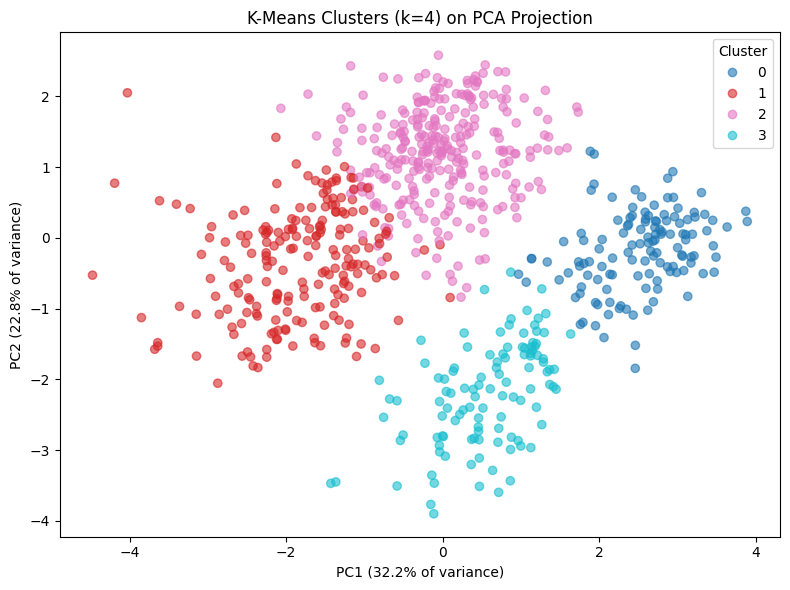

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Find suitable number of clusters
inertias = []
sil_scores = []
K_range = range(2,11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Plot the Elbow Method
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(list(K_range), inertias, marker='o')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

# Plot the Silhouette Score
axes[1].plot(list(K_range), sil_scores, marker='o', color='seagreen')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')
plt.tight_layout()
plt.show()

for k, inertia, sil in zip(K_range, inertias, sil_scores):
    print(f"k={k}: inertia={inertia:.1f}, silhouette={sil:.4f}")

# Choose the final k
FINAL_K = 4
kmeans_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
daily_agg['kmeans_cluster'] = kmeans_final.fit_predict(X_scaled)

print("\nFinal cluster sizes:")
print(daily_agg['kmeans_cluster'].value_counts().sort_index())

# Report centroids in the original feature scale
centroids_original_scale = daily_agg.groupby('kmeans_cluster')[final_features].mean().round(3)
print("\nCluster centroids:")
print(centroids_original_scale.T)

# Visualise the clusters using PCA
plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_coords[:, 0], pca_coords[:, 1],
                       c=daily_agg['kmeans_cluster'], cmap='tab10', alpha=0.6)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% of variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% of variance)')
plt.title(f'K-Means Clusters (k={FINAL_K}) on PCA Projection')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.tight_layout()
plt.show()



### 2.2 Hierarchical Clustering (AGNES)

In [ ]:
# Step 6 code goes here.


### 2.3 DBSCAN

In [ ]:
# Step 7 code goes here.


## Part 3: Clustering Evaluation and Comparison

In [ ]:
# Step 8 code goes here.


## Part 4: Cluster Interpretation and Validation

In [ ]:
# Step 9 code goes here.


## Part 5: Theoretical Understanding
Written answers to the 10 theory questions — drafted together with the report in Step 10.